# Local COCO image-loading smoke test

This notebook validates image discovery, preprocessing, batching, and separate K-FRAG token packet generation. The in-memory HMAC key is never displayed.

In [1]:
from pathlib import Path
import secrets
import sys

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def find_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'kfrag').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the K-FRAG repository root')

repository_root = find_repository_root(Path.cwd())
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

from kfrag.crypto import ProvenanceToken, create_packets
from kfrag.data import CocoImageDataset

In [2]:
config_path = repository_root / 'configs' / 'local_coco_smoke.yaml'
config = {'data': {}}
for line in config_path.read_text(encoding='utf-8').splitlines():
    stripped = line.strip()
    if not stripped or stripped == 'data:':
        continue
    key, value = (part.strip() for part in stripped.split(':', 1))
    config['data'][key] = int(value) if value.isdigit() else value

data_config = config['data']
image_directory = repository_root / data_config['root']
dataset = CocoImageDataset(image_directory)
assert len(dataset) == data_config['expected_images']

sample = dataset[0]
print(f"Images found: {len(dataset)}")
print(f"Single image tensor shape: {sample['image'].shape}")

Images found: 100
Single image tensor shape: torch.Size([3, 256, 256])


In [3]:
loader = DataLoader(
    dataset,
    batch_size=data_config['batch_size'],
    num_workers=data_config['num_workers'],
    shuffle=False,
)
batch = next(iter(loader))
print(f"Batch tensor shape: {batch['image'].shape}")

Batch tensor shape: torch.Size([4, 3, 256, 256])


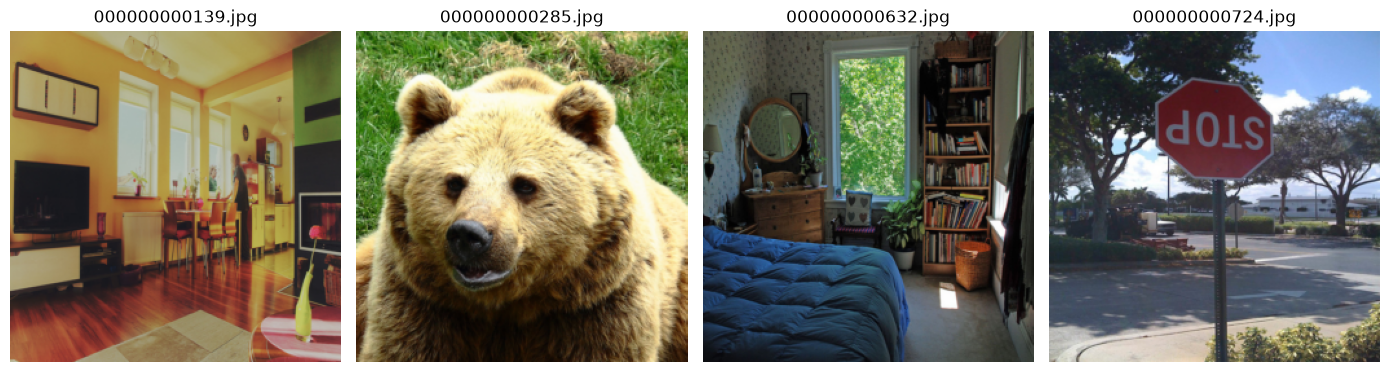

In [4]:
figure, axes = plt.subplots(1, 4, figsize=(14, 4))
for axis, image, filename in zip(axes, batch['image'], batch['filename']):
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(filename)
    axis.axis('off')
figure.tight_layout()
plt.show()

In [5]:
secret_key = secrets.token_bytes(32)  # Kept in memory and never printed.
tokens = [ProvenanceToken.generate(issuer_id=42, version=1) for _ in range(4)]
packet_sets = [create_packets(token, secret_key) for token in tokens]

for filename, token, packets in zip(batch['filename'], tokens, packet_sets):
    assert len(packets) == 16
    print(
        f"filename={filename}, issuer_id={token.issuer_id}, "
        f"asset_id={token.asset_id}, version={token.version}, packets={len(packets)}"
    )

filename=000000000139.jpg, issuer_id=42, asset_id=13961488918638415397, version=1, packets=16
filename=000000000285.jpg, issuer_id=42, asset_id=13480111965265837253, version=1, packets=16
filename=000000000632.jpg, issuer_id=42, asset_id=5894632386113888018, version=1, packets=16
filename=000000000724.jpg, issuer_id=42, asset_id=18410382618146399020, version=1, packets=16
